# Factor Bar Chart and Timeseries Figures

In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

In [2]:
# force the math text to look normal
mpl.rcParams['mathtext.default'] = 'regular'

def major_ticks(x, pos=None):
    """Set the major ticks according
    to this custom style
    """
    x = mdates.num2date(x)
    if pos == 0:
        fmt = "%-d\n%b %Y\n%I %p"
    else:
        fmt = "%-d"
    return x.strftime(fmt)

# set the default seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [3]:
#load in the comp data
comp = pd.read_csv('680_factor_resid.csv')
comp.rename(columns={'Unnamed: 0':'species'},inplace=True)
comp

,species,Factor 1,Factor 2,Factor 3,Factor 4,Residual
0,co,0.548644,0.133169,0.009322,0.294021,0.014844
1,no,0.540810,0.114254,0.000000,0.325392,0.019544
2,no2,0.972160,0.021453,0.012521,0.000000,-0.006134
3,o3,0.306759,0.000000,0.000000,0.700444,-0.007203
4,bin0,0.001685,0.821637,0.000000,0.202107,-0.025429
5,bin1,0.000000,0.738025,0.369701,0.000000,-0.107726
6,bin2,0.000000,0.390766,0.644228,0.000000,-0.034993
7,bin3,0.081021,0.117268,0.765759,0.039154,-0.003203
8,bin4,0.145212,0.000000,0.665375,0.192019,-0.002606
9,bin5,0.262145,0.000000,0.470956,0.263516,0.003383


In [4]:
comp2 = pd.melt(comp,id_vars='species', value_vars=['Factor 1','Factor 2','Factor 3','Residual'])
comp2

,species,variable,value
0,co,Factor 1,0.548644
1,no,Factor 1,0.540810
2,no2,Factor 1,0.972160
3,o3,Factor 1,0.306759
4,bin0,Factor 1,0.001685
5,bin1,Factor 1,0.000000
6,bin2,Factor 1,0.000000
7,bin3,Factor 1,0.081021
8,bin4,Factor 1,0.145212
9,bin5,Factor 1,0.262145


In [5]:
#load in the timeseries data
ts = pd.read_csv('MOD-000680_timeseries_hourly_scaled.csv').reset_index()
results = pd.read_csv('680_factor_results.csv')

ts = pd.concat([ts,results['Factor 1'],results['Factor 2'], results['Factor 3']], axis = 1)
cols_reordered = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','co','o3','no','no2','Factor 1','Factor 2','Factor 3']
ts = ts[cols_reordered]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
0,2025-03-31 20:00:00,0.284336,0.101296,0.073262,0.086003,0.132827,0.293478,0.537031,0.316643,0.033910,0.685166,0.062073,0.057488,0.079925
1,2025-03-31 21:00:00,0.319940,0.174254,0.098396,0.101180,0.151803,0.364130,0.522884,0.333517,0.044154,0.651614,0.056460,0.065106,0.108501
2,2025-03-31 22:00:00,0.316261,0.264697,0.131551,0.118044,0.153700,0.315217,0.556833,0.312893,0.049629,0.735387,0.063930,0.072245,0.119402
3,2025-03-31 23:00:00,0.138538,0.086825,0.044920,0.038786,0.049336,0.092391,0.421759,0.544833,0.043448,0.419076,0.037907,0.021704,0.032941
4,2025-04-01 00:00:00,0.173048,0.112150,0.058289,0.050590,0.060721,0.114130,0.410638,0.516709,0.042918,0.560878,0.049351,0.026138,0.043470


In [6]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local']) #convert timestamp column to pandas timestamp format
ts = ts.set_index('timestamp_local',append=False) #setindex as local time
ts

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,0.284336,0.101296,0.073262,0.086003,0.132827,0.293478,0.537031,0.316643,0.033910,0.685166,0.062073,0.057488,0.079925
2025-03-31 21:00:00,0.319940,0.174254,0.098396,0.101180,0.151803,0.364130,0.522884,0.333517,0.044154,0.651614,0.056460,0.065106,0.108501
2025-03-31 22:00:00,0.316261,0.264697,0.131551,0.118044,0.153700,0.315217,0.556833,0.312893,0.049629,0.735387,0.063930,0.072245,0.119402
2025-03-31 23:00:00,0.138538,0.086825,0.044920,0.038786,0.049336,0.092391,0.421759,0.544833,0.043448,0.419076,0.037907,0.021704,0.032941
2025-04-01 00:00:00,0.173048,0.112150,0.058289,0.050590,0.060721,0.114130,0.410638,0.516709,0.042918,0.560878,0.049351,0.026138,0.043470
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 14:00:00,0.070811,0.021103,0.012299,0.008432,0.005693,0.010870,0.434716,0.323370,0.033557,0.633678,0.062304,0.014804,0.000000
2025-12-31 15:00:00,0.066534,0.020802,0.011765,0.008432,0.007590,0.010870,0.438226,0.315540,0.036913,0.642330,0.063326,0.014383,0.000000
2025-12-31 16:00:00,0.076778,0.026229,0.014973,0.010118,0.007590,0.010870,0.462462,0.292820,0.042388,0.655202,0.065031,0.019549,0.000000


In [7]:
#taking daily average of ts. round to floor of the day
ts = ts.reset_index()

ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  factor1 = ('Factor 1','mean'),
                                                  factor2 = ('Factor 2','mean'),
                                                  factor3 = ('Factor 3','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,factor1,factor2,factor3
timestamp_local,,,,,,,,,,,,,
2025-03-31,0.264769,0.156768,0.087032,0.086003,0.121917,0.266304,0.509627,0.376971,0.042785,0.622811,0.055093,0.054136,0.085192
2025-04-01,0.052080,0.024194,0.012322,0.009837,0.011227,0.019475,0.378604,0.488011,0.038370,0.317516,0.031311,0.006923,0.005384
2025-04-02,0.043888,0.024910,0.022014,0.027754,0.040955,0.084918,0.439644,0.517568,0.036125,0.500290,0.048239,0.002541,0.022721
2025-04-03,0.242152,0.145450,0.075914,0.073848,0.115117,0.268569,0.504172,0.345226,0.042484,0.535442,0.048056,0.053906,0.080760
2025-04-04,0.054293,0.019307,0.012032,0.011734,0.015971,0.031929,0.412632,0.456141,0.036206,0.327223,0.033277,0.010536,0.005852


## Setting Up Barchart and 6-month Figures

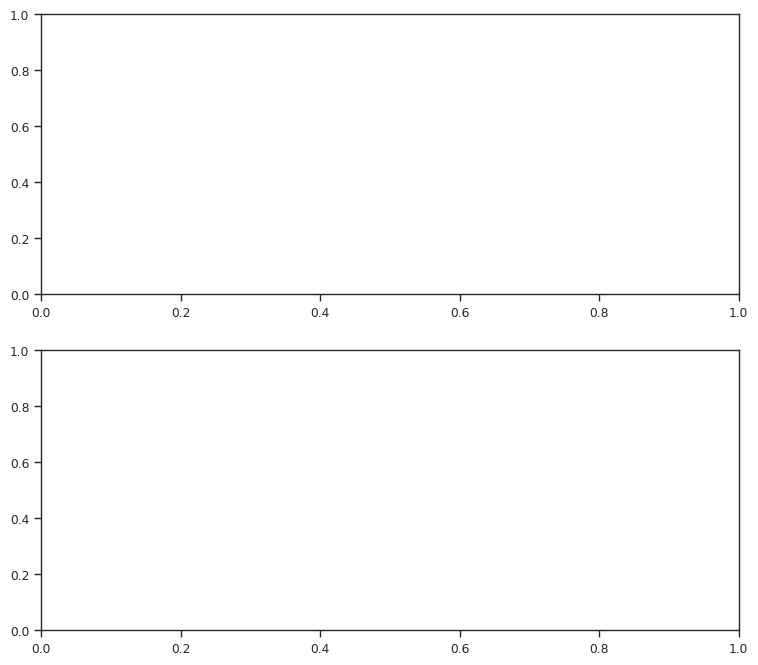

In [8]:
# set up the figure
fig = plt.figure(figsize=(9, 8))

ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

In [9]:
cols = ['bin0', 'bin1', 'bin2','bin3','bin4','bin5','co', 'o3','no', 'no2']

pal = sns.color_palette()

colors = [pal[3], pal[2], pal[4], pal[5]]
colors += sns.color_palette("Blues", 6)
colors.reverse()

In [10]:
ax1 = sns.barplot(x='variable',y='value',
        data=comp2,
        ax=ax1, hue='species',hue_order=cols,
        palette=colors, saturation=1, edgecolor='black', linewidth=0.25,
        errwidth=.75)

/tmp/ipykernel_479/2976516543.py:1: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  ax1 = sns.barplot(x='variable',y='value',


In [11]:
ax1.set_ylim(-0.2, 1)
ax1.set_xlabel("")
ax1.set_ylabel("Percent of Species Signal\nDescribed by Factor", fontsize=14)
ax1.set(yticks=np.linspace(-0.2, 1, 13), yticklabels=["","","0","","","","","50","","","","","100"])
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.axhline(y=0, color='black', linestyle='-', lw =0.5)

In [12]:
handles, _ = ax1.get_legend_handles_labels()
labels = ["Bin 0", "Bin 1", "Bin 2", "Bin 3","Bin 4","Bin 5","CO","$O_3$","$NO$", "$NO_2$"]
ax1.legend(handles, labels)

In [13]:
ax2.plot(ts_day.index, ts_day["factor1"], label="Factor 1 ", lw=1, color=sns.xkcd_rgb['slate blue'])
ax2.plot(ts_day.index, ts_day["factor2"], label="Factor 2", lw=1, color=sns.xkcd_rgb['dull green'])
ax2.plot(ts_day.index, ts_day["factor3"], label="Factor 3", lw=1, color=sns.xkcd_rgb['dark lavender'])

ax2.set_ylabel("Factor Intensity (a.u.)", fontsize=14)

#last 6 months
ax2.set_xlim(ts_day.index[-180], ts_day.index[-1])
#ax2.set_xlim(ts_day.index[0], ts_day.index[-1])

ax2.legend(loc='upper right',fontsize=10)
ax2.tick_params(axis='both', which='major', labelsize=14)

In [14]:
ax1.set_title('(a)',fontsize=14)
ax2.set_title('(b)',fontsize=14)

Text(0.5, 1.0, '(b)')

In [15]:
plt.gcf().text(0.09, 0.9, "(a)", fontsize=12)
plt.gcf().text(0.5, 0.9, "(b)", fontsize=12)
plt.gcf().text(0.09,0.9,'MOD-00397',fontsize=12)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [16]:
import os

# Create the directory if it doesn't exist
os.makedirs('MOD-00680', exist_ok=True)

fig.savefig('MOD-00680/time_barchart_MOD-000680_4_factor.png')

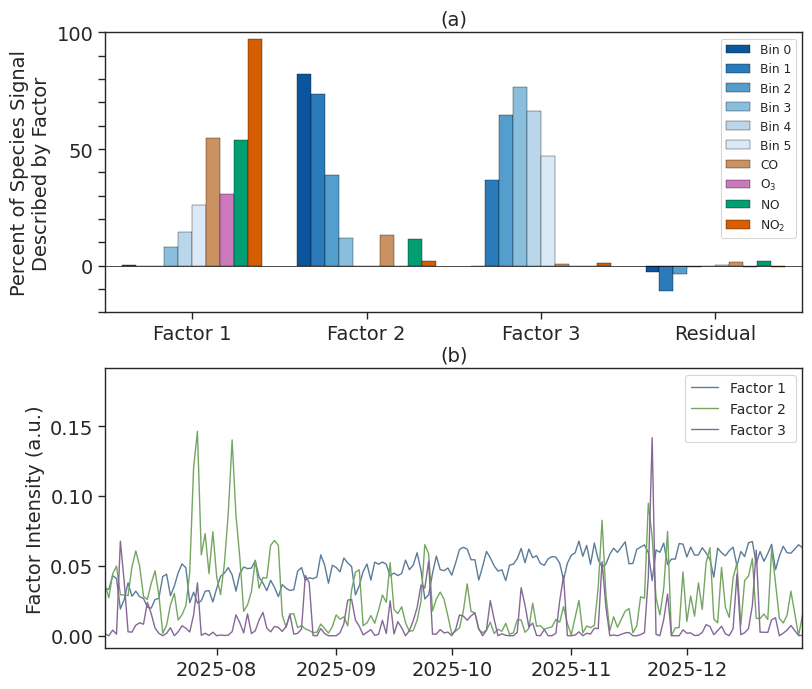

In [17]:
fig

## Setting Up Diurnal Figure

In [18]:
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3
0,2025-03-31 20:00:00,0.284336,0.101296,0.073262,0.086003,0.132827,0.293478,0.537031,0.316643,0.033910,0.685166,0.062073,0.057488,0.079925
1,2025-03-31 21:00:00,0.319940,0.174254,0.098396,0.101180,0.151803,0.364130,0.522884,0.333517,0.044154,0.651614,0.056460,0.065106,0.108501
2,2025-03-31 22:00:00,0.316261,0.264697,0.131551,0.118044,0.153700,0.315217,0.556833,0.312893,0.049629,0.735387,0.063930,0.072245,0.119402
3,2025-03-31 23:00:00,0.138538,0.086825,0.044920,0.038786,0.049336,0.092391,0.421759,0.544833,0.043448,0.419076,0.037907,0.021704,0.032941
4,2025-04-01 00:00:00,0.173048,0.112150,0.058289,0.050590,0.060721,0.114130,0.410638,0.516709,0.042918,0.560878,0.049351,0.026138,0.043470


In [19]:
#prepping data
ts = ts.set_index('timestamp_local')
ts['Hour'] = ts.index.hour
ts.head()

,bin0,bin1,bin2,bin3,bin4,bin5,co,o3,no,no2,Factor 1,Factor 2,Factor 3,Hour
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,0.284336,0.101296,0.073262,0.086003,0.132827,0.293478,0.537031,0.316643,0.033910,0.685166,0.062073,0.057488,0.079925,20
2025-03-31 21:00:00,0.319940,0.174254,0.098396,0.101180,0.151803,0.364130,0.522884,0.333517,0.044154,0.651614,0.056460,0.065106,0.108501,21
2025-03-31 22:00:00,0.316261,0.264697,0.131551,0.118044,0.153700,0.315217,0.556833,0.312893,0.049629,0.735387,0.063930,0.072245,0.119402,22
2025-03-31 23:00:00,0.138538,0.086825,0.044920,0.038786,0.049336,0.092391,0.421759,0.544833,0.043448,0.419076,0.037907,0.021704,0.032941,23
2025-04-01 00:00:00,0.173048,0.112150,0.058289,0.050590,0.060721,0.114130,0.410638,0.516709,0.042918,0.560878,0.049351,0.026138,0.043470,0


In [20]:
#grouping by hour and calculate the mean
diurnal_data = ts.groupby('Hour')[['Factor 1','Factor 2','Factor 3']].mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,Factor 1,Factor 2,Factor 3
Hour,,,
00:00,0.048737,0.029376,0.018268
01:00,0.048547,0.028770,0.017311
02:00,0.047975,0.028346,0.016067
03:00,0.047644,0.029743,0.016686
04:00,0.047714,0.030006,0.017818
05:00,0.048596,0.031873,0.019131
06:00,0.049459,0.032720,0.020011
07:00,0.046949,0.034775,0.017353
08:00,0.040393,0.034229,0.014972


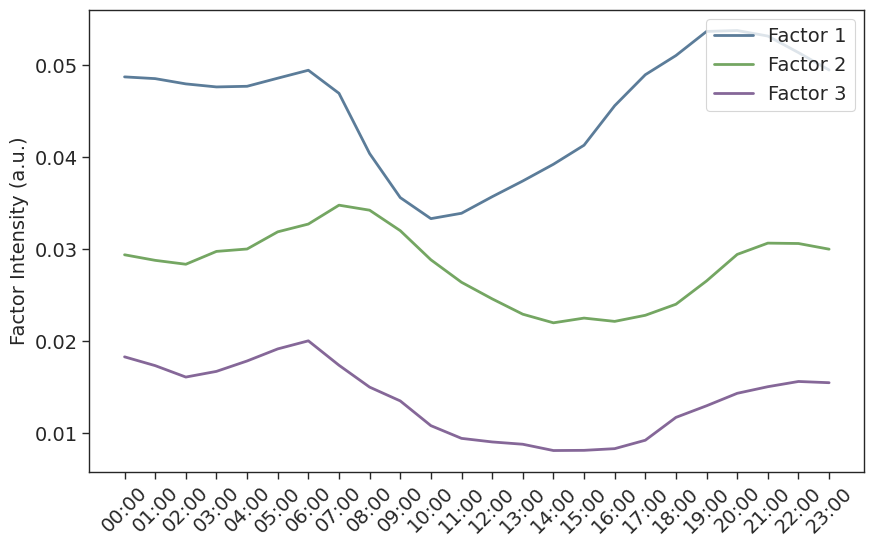

In [21]:
# set up the figure
plt.figure(figsize=(10, 6))

plt.plot(diurnal_data.index, diurnal_data['Factor 1'], label='Factor 1', lw = 2, color=sns.xkcd_rgb['slate blue'])
plt.plot(diurnal_data.index, diurnal_data['Factor 2'], label='Factor 2', lw = 2, color=sns.xkcd_rgb['dull green'])
plt.plot(diurnal_data.index, diurnal_data['Factor 3'], label='Factor 3', lw = 2, color=sns.xkcd_rgb['dark lavender'])

plt.ylabel('Factor Intensity (a.u.)', fontsize = 14)
plt.legend(loc='upper right',fontsize=14)
plt.xticks(range(0, 24))
plt.xticks(rotation=45)

plt.tick_params(labelsize=14)

plt.savefig('MOD-00680/diurnal_MOD-000680_4_factor.png')
plt.show()